<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/VaR_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota: Por vezes aparecem umas mensagens algo irritantes resultantes de uma brincadeira que o Google Colab decidiu fazer no dia 1 Abril de 2024. Podem retirar essas interrupções em Settings > Miscellaneous > Power level e escolhendo: No power

In [94]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
    Updating `/content/new_envir/Project.toml`
  [4015ef85] ~ Caramel v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main` ⇒ v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main`
    Updating `/content/new_envir/Manifest.toml`
  [4015ef85] ~ Caramel v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main` ⇒ v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main`
Precompiling packages...
   8650.8 ms  ✓ Caramel
  1 dependency successfully precompiled in 9 seconds. 254 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version


In [106]:
using Caramel, Plots

In [96]:
# Pretendemos obter as cotações diárias (ajustadas) de fecho da Apple, entre 1 Outubro 2020 e 15 de Março de 2025

apple = AssetPrice("AAPL", Date(2020,10,01), Date(2025,03,15)) |> DataFrame
show(apple)

# "AAPL" é o símbolo da Apple na bolsa NASDAQ

1118×3 DataFrame
  Row │ ticker  date        adjclose
      │ String  Date        Float64
──────┼──────────────────────────────
    1 │ AAPL    2020-10-01   113.882
    2 │ AAPL    2020-10-02   110.206
    3 │ AAPL    2020-10-05   113.599
    4 │ AAPL    2020-10-06   110.342
    5 │ AAPL    2020-10-07   112.214
    6 │ AAPL    2020-10-08   112.107
    7 │ AAPL    2020-10-09   114.057
    8 │ AAPL    2020-10-12   121.302
    9 │ AAPL    2020-10-13   118.084
   10 │ AAPL    2020-10-14   118.172
   11 │ AAPL    2020-10-15   117.704
  ⋮   │   ⋮         ⋮          ⋮
 1109 │ AAPL    2025-03-03   238.03
 1110 │ AAPL    2025-03-04   235.93
 1111 │ AAPL    2025-03-05   235.74
 1112 │ AAPL    2025-03-06   235.33
 1113 │ AAPL    2025-03-07   239.07
 1114 │ AAPL    2025-03-10   227.48
 1115 │ AAPL    2025-03-11   220.84
 1116 │ AAPL    2025-03-12   216.98
 1117 │ AAPL    2025-03-13   209.68
 1118 │ AAPL    2025-03-14   213.49
                    1097 rows omitted

In [97]:
# Selecionamos todas as linhas (:) mas apenas a coluna :adjclose para criar um vetor contendo somente as cotações de fecho ajustadas em vez do dataframe que tinhamos antes

adjclose = apple[:, :adjclose];

# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.


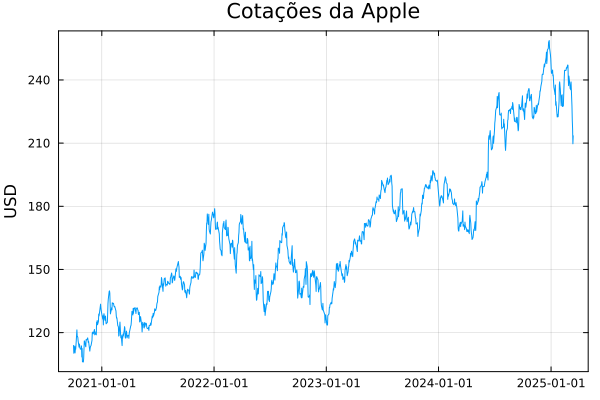

In [98]:
fig1 = plot(apple[:,:date], adjclose, title="Cotações da Apple",legend = false,ylabel="USD", framestyle = :box)

In [99]:
# Agora que inspecionámos a evolução de cotações da Apple, vamos calcular os retornos (logaritmicos),

logr = LogReturn("AAPL", Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(logr)

# Para analisar séries cronológicas é normalmente mais indicado a utilização de retornos logarítmicos (log(Pt/Pt-1)). Notemos que Julia denota por log() a função que calcula o logarítmo de base e. Para agregação sectional, por exemplo se pretendermos calcular o retorno de uma carteira, devemos antes utilizar os retornos simples ((Pt-Pt-1)/Pt-1)

1068×5 DataFrame
  Row │ ticker  date        interval  type    r
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ AAPL    2020-10-02  1d        log     -0.032813
    2 │ AAPL    2020-10-05  1d        log      0.030326
    3 │ AAPL    2020-10-06  1d        log     -0.029088
    4 │ AAPL    2020-10-07  1d        log      0.016825
    5 │ AAPL    2020-10-08  1d        log     -0.000956
    6 │ AAPL    2020-10-09  1d        log      0.017246
    7 │ AAPL    2020-10-12  1d        log      0.061585
    8 │ AAPL    2020-10-13  1d        log     -0.026886
    9 │ AAPL    2020-10-14  1d        log      0.000743
   10 │ AAPL    2020-10-15  1d        log     -0.003969
   11 │ AAPL    2020-10-16  1d        log     -0.0141
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ AAPL    2024-12-17  1d        log      0.009673
 1060 │ AAPL    2024-12-18  1d        log     -0.021655
 1061 │ AAPL    2024-12-19  1d        log     

In [100]:
# Selecionamos todas as linhas (:) agora do dataframe logr e apenas a coluna :r.
r = logr[:,:r];

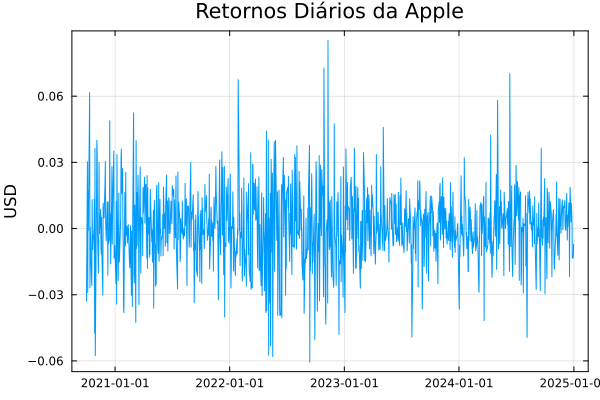

In [101]:
fig2 = plot(logr[:,:date], r, title="Retornos Diários da Apple",legend = false, ylabel="USD", framestyle = :box)

In [102]:
# Vamos calcular de seguida (i) a média e o (ii) desvio-padrão dos retornos diários,

mu = mean(r)
sigma = std(r)
println("média = $(mu) e desvio-padrão = $(sigma)")

# Usamos $, como em " $(x) ", para intercalar o valor da variavel (x) no texto.
# O texto tem que estar entre " ".

média = 0.0007367696629213483 e desvio-padrão = 0.017069949227877124


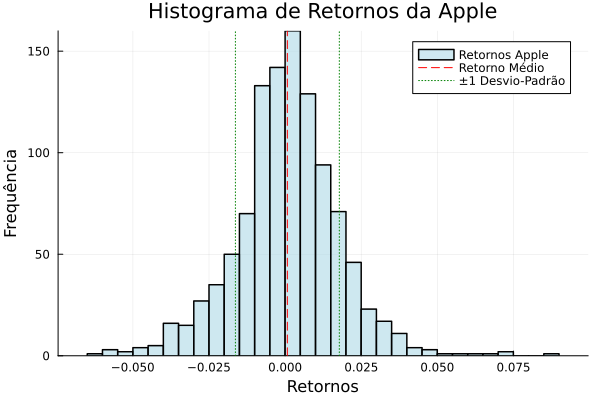

In [104]:
# Podemos visualizar o histograma dos retorns diário da Apple usando o método histogram() da biblioteca Plots

fig3 = histogram(r,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos Apple",
          xlabel="Retornos",
          ylabel="Frequência",
          title="Histograma de Retornos da Apple",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e desvio-padrão

vline!([mu], linecolor=:red, linestyle=:dash, label="Retorno Médio")
vline!([mu - sigma, mu + sigma],
       linecolor=:green, linestyle=:dot, label="±1 Desvio-Padrão")

# O gráfico sugere que a observação de valores extremos ocorrerá com alguma frequência

display(plot!(fig3))

Em que medida uma distribuição normal representa bem a realidade empírica dos retornos da Apple observados nos últimos anos?
*   Inspeção Visual
  * $\surd$ Histograma
  * Gráficos Quantil-Quantil (infelizmente não existe no Plots)
*   Testes Estatísticos de Normalidade
  * Teste de Shapiro-Wilk
  * Teste de Kolmogorov-Smirnov
  * Teste de Anderson-Darling (bastante útil para a nossa análise de risco de perda, pois é particularmente sensível a desvios na cauda da distribuição)



In [108]:
# Embora o Plots não tenha gráficos Quantil-Quantil (QQ) pré-definidos a biblioteca Caramel tem.

qqplot(r)

LoadError: UndefVarError: `qqplot` not defined